In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

In [6]:
# % pip install scikit-learn scipy

In [7]:
csv_path = r'C:\Users\user\Desktop\div\data\files\housing.csv'
df = pd.read_csv(csv_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
m = df['median_income'].mean()
m

np.float64(3.8706710029069766)

In [9]:
s = df['median_income'].std()
s

np.float64(1.8998217179452688)

In [10]:
m - 3*s if m - 3*s >= 0 else 0, m+ 3*s

(0, np.float64(9.570136156742784))

In [11]:
outlier_mask = ~df['median_income'].between(m - 3*s if m - 3*s >= 0 else 0, m + 3*s)
df.loc[outlier_mask, :]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
409,-117.87,33.64,26.0,3521.0,455.0,1336.0,451.0,10.2849,500001.0,<1H OCEAN
478,-117.58,33.60,5.0,5348.0,659.0,1862.0,555.0,11.0567,495400.0,<1H OCEAN
480,-118.32,34.07,52.0,2980.0,366.0,967.0,359.0,11.2185,500001.0,<1H OCEAN
515,-118.41,34.07,52.0,3562.0,394.0,1163.0,361.0,15.0001,500001.0,<1H OCEAN
546,-122.21,37.38,28.0,4518.0,578.0,1489.0,559.0,11.3176,500001.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
20392,-117.77,33.80,16.0,3973.0,483.0,1373.0,452.0,9.8074,417000.0,<1H OCEAN
20426,-122.08,37.84,17.0,1320.0,159.0,1722.0,141.0,11.7064,500001.0,NEAR BAY
20466,-117.24,32.85,22.0,3479.0,448.0,1252.0,440.0,10.0707,500001.0,NEAR OCEAN
20492,-117.18,33.02,15.0,3540.0,453.0,1364.0,425.0,13.6623,500001.0,NEAR OCEAN


In [12]:
means = df.select_dtypes('number').mean()
stds = df.select_dtypes('number').std()

lower_limits = means - 3 * stds
upper_limits = means + 3 * stds

In [13]:
lower_outlier_mask = df.select_dtypes('number') < lower_limits
upper_outlier_mask = df.select_dtypes('number') > upper_limits

In [14]:
outliers_mask = lower_outlier_mask.any(axis=1) | upper_outlier_mask.any(axis=1) 
outliers_mask

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Length: 20640, dtype: bool

In [15]:
lower_outlier_mask

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False


In [16]:
df.loc[outliers_mask, :]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
95,-122.26,37.80,36.0,5329.0,2477.0,3469.0,2323.0,2.0096,130000.0,NEAR BAY
117,-117.47,34.12,6.0,10565.0,1767.0,5690.0,1555.0,4.1797,141000.0,INLAND
146,-122.51,38.06,24.0,9493.0,1935.0,5162.0,1880.0,3.0742,118800.0,NEAR BAY
158,-116.39,33.69,10.0,11659.0,2007.0,2186.0,1083.0,6.9833,238800.0,INLAND
212,-122.04,37.39,5.0,8745.0,2211.0,3959.0,2019.0,4.7685,280100.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
20494,-118.12,34.13,52.0,2935.0,341.0,975.0,327.0,11.7060,500001.0,<1H OCEAN
20543,-121.74,38.55,33.0,6861.0,1820.0,3717.0,1767.0,1.7311,182600.0,INLAND
20544,-121.76,38.55,23.0,8800.0,1857.0,6330.0,1832.0,2.0650,219400.0,INLAND
20563,-121.75,38.67,9.0,12139.0,2640.0,6837.0,2358.0,3.1250,132500.0,INLAND


In [17]:
q1 = df.select_dtypes('number').quantile(0.25)
q3 = df.select_dtypes('number').quantile(0.75)

iqr = q3 - q1



In [18]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(df[['median_income', 'median_house_value']])
ss.transform(df[['median_income', 'median_house_value']])

array([[ 2.34476576,  2.12963148],
       [ 2.33223796,  1.31415614],
       [ 1.7826994 ,  1.25869341],
       ...,
       [-1.14259331, -0.99274649],
       [-1.05458292, -1.05860847],
       [-0.78012947, -1.01787803]], shape=(20640, 2))

In [19]:
df['median_income'].mean()

np.float64(3.8706710029069766)

array([[<Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

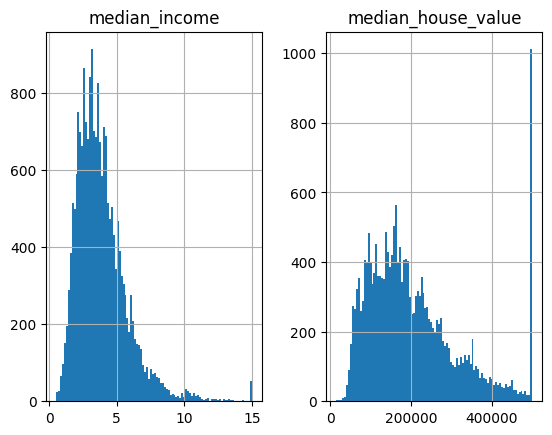

In [20]:
df[['median_income', 'median_house_value']].hist(bins=100)

In [21]:
df2 = df[['median_income', 'median_house_value']]
means = df2.mean()
stds = df2.std()

array([[<Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

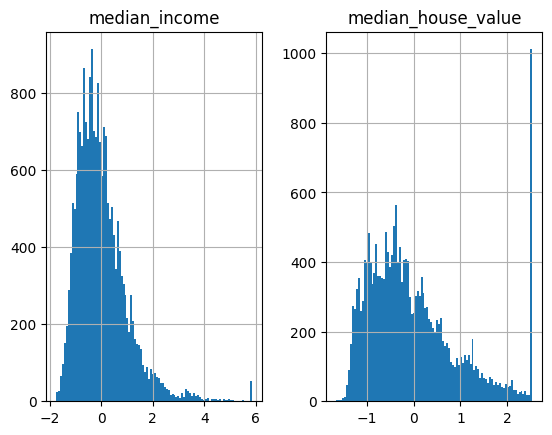

In [22]:
(
	(df2 - means)/stds
).hist(bins=100)	

<Axes: ylabel='Count'>

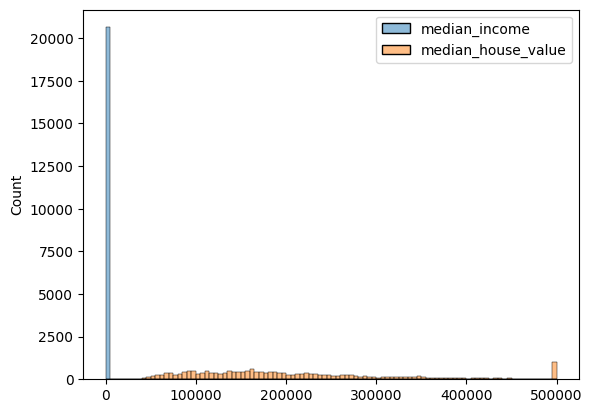

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(
	df[['median_income', 'median_house_value']], 
	bins=100
)

In [24]:
# class Heyvan:
# 	def __init__(self, ad='it'):
# 		ad = ad

# h1 = Heyvan()

In [25]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(df[['median_income', 'median_house_value']])
df_yeni = ss.transform(df[['median_income', 'median_house_value']])
np.logical_or(df_yeni > 3, df_yeni < -3).any(axis=1)

array([False, False, False, ..., False, False, False], shape=(20640,))

In [26]:
# np.random.normal(200000, 60000, size=20000)
# np.random.normal(0, 1, size=20000)
np.random.standard_normal(size=20000)

array([ 0.31763947,  0.17616571, -0.10934556, ..., -0.02146432,
       -0.24625186,  1.00281019], shape=(20000,))

In [27]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
rs.fit(df[['median_income', 'median_house_value']])
df_yeni = rs.transform(df[['median_income', 'median_house_value']])
pd.DataFrame(df_yeni, columns=['median_income', 'median_house_value'])

,median_income,median_house_value
0,2.197582,1.880448
1,2.186664,1.232041
2,1.707732,1.187941
3,0.967177,1.113523
4,0.142854,1.119724
...,...,...
20635,-0.905796,-0.700086
20636,-0.448655,-0.706977
20637,-0.841709,-0.602239
20638,-0.765007,-0.654608


In [28]:
help(RobustScaler)

Help on class RobustScaler in module sklearn.preprocessing._data:

class RobustScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  RobustScaler(*, with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), copy=True, unit_variance=False)
 |  
 |  Scale features using statistics that are robust to outliers.
 |  
 |  This Scaler removes the median and scales the data according to
 |  the quantile range (defaults to IQR: Interquartile Range).
 |  The IQR is the range between the 1st quartile (25th quantile)
 |  and the 3rd quartile (75th quantile).
 |  
 |  Centering and scaling happen independently on each feature by
 |  computing the relevant statistics on the samples in the training
 |  set. Median and interquartile range are then stored to be used on
 |  later data using the :meth:`transform` method.
 |  
 |  Standardization of a dataset is a common preprocessing for many machine
 |  learning estimators. Typically this is 

In [29]:
from sklearn.preprocessing import MinMaxScaler

df2 = df[['median_house_value', 'median_income']]
mm = MinMaxScaler()
mm.fit(df2)
mm.transform(df2)

array([[0.90226638, 0.53966842],
       [0.70824656, 0.53802706],
       [0.69505074, 0.46602805],
       ...,
       [0.15938285, 0.08276438],
       [0.14371281, 0.09429525],
       [0.15340349, 0.13025338]], shape=(20640, 2))

In [30]:
import pandas as pd

In [31]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(df[['median_income', 'median_house_value']])
df_yeni = ss.transform(df[['median_income', 'median_house_value']])
df_yeni = pd.DataFrame(df_yeni, columns=['median_income', 'median_house_value'])

<Axes: ylabel='Frequency'>

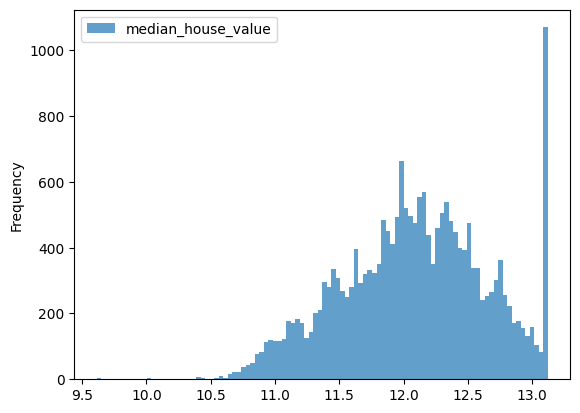

In [ ]:
np.log(df[['median_house_value']] + 1).plot(kind='hist', bins=100, alpha=0.7)

In [41]:
np.e ** 13

442413.3920089202

<Axes: ylabel='Frequency'>

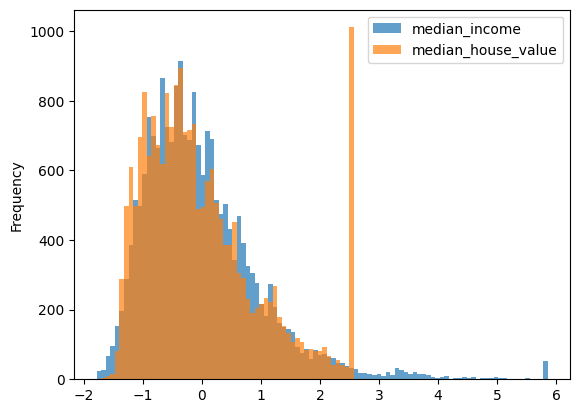

In [34]:
df_yeni.plot(kind='hist', bins=100, alpha=0.7)

In [45]:
x = np.random.randint(0,10,20)
x

array([0, 5, 0, 4, 6, 6, 6, 2, 7, 2, 9, 1, 0, 2, 7, 6, 1, 4, 2, 1],
      dtype=int32)

In [47]:
np.log(x + 1)

array([0.        , 1.79175947, 0.        , 1.60943791, 1.94591015,
       1.94591015, 1.94591015, 1.09861229, 2.07944154, 1.09861229,
       2.30258509, 0.69314718, 0.        , 1.09861229, 2.07944154,
       1.94591015, 0.69314718, 1.60943791, 1.09861229, 0.69314718])